<a href="https://colab.research.google.com/github/ABamukhayyar/AI_stock_Market_Prediction/blob/AI-models/testing_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Regression

## Importing the libraries

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [43]:
dataset = pd.read_csv('SABIC Stock Price History.csv')


In [44]:
# Convert 'Date' to datetime just in case
dataset['Date'] = pd.to_datetime(dataset['Date'], format='mixed', dayfirst=False)

# Sort from Oldest to Newest
dataset = dataset.sort_values('Date', ascending=True).reset_index(drop=True)
# Reset the index so the numbers start from 0 again
dataset = dataset.reset_index(drop=True)
# C. Remove '%' from Change columnA
# Check if column is string before fixing (in case pandas already read it as float)
if dataset['Change %'].dtype == object:
    dataset['Change %'] = dataset['Change %'].str.replace('%', '').astype(float)

# D. Remove Commas ',' from Price columns
cols_to_fix = ['Price', 'Open', 'High', 'Low']
for col in cols_to_fix:
    if dataset[col].dtype == object: # Only if it's currently a string
        dataset[col] = dataset[col].str.replace(',', '').astype(float)
# Clean Volume (Crucial Step!)
def clean_volume(x):
    if isinstance(x, str):
        x = x.upper().replace(',', '')
        if 'M' in x: return float(x.replace('M', '')) * 1_000_000
        if 'B' in x: return float(x.replace('B', '')) * 1_000_000_000
        if 'K' in x: return float(x.replace('K', '')) * 1_000
    return float(x)

dataset['Vol.'] = dataset['Vol.'].apply(clean_volume).fillna(0)

# 1. CREATE THE NEW TARGET
# "shift(-1)" moves all prices UP by one day.
# So Row 0 (Jan 1) now contains the Price of Jan 2.
dataset['Next_Day_Price'] = dataset['Price'].shift(-1)
# 2. DROP THE LAST ROW
# The very last day of your data (e.g., 2026) has no "Tomorrow",
# so 'Next_Day_Price' will be NaN (Empty). We must remove it.
dataset = dataset.dropna()

print("Data Cleaned Successfully!")
print(dataset.head())
print(dataset['Date'].dtype)
# ... (Previous cleaning code for Date, Commas, Volume) ...

print("Checking for NaNs before fixing...")
print(dataset.isnull().sum()) # This will show you which columns have blanks

# --- THE FIX: DROP ROWS WHERE PRICE IS MISSING ---
dataset = dataset.dropna(subset=['Price'])

# Optional: Double check that X columns don't have NaNs either
# If you used fillna(0) on Volume earlier, you should be safe.
# But just in case, let's drop rows where ANY feature is missing to be safe
dataset = dataset.dropna()

print("Rows remaining after dropping NaNs:", len(dataset))

# --- ADDING TECHNICAL INDICATORS ---

# 1. SMA_20 (20-Day Simple Moving Average)
# Helps the model see the "Trend"
dataset['SMA_20'] = dataset['Price'].rolling(window=20).mean()

# 2. RSI (Relative Strength Index)
# Helps the model see "Overbought/Oversold"
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

dataset['RSI'] = calculate_rsi(dataset['Price'])

# 3. Clean up NaNs created by the indicators
# (First 20 days will be empty because they don't have enough history)
dataset = dataset.dropna()

print("Indicators Added: SMA_20 and RSI")
print(dataset[['Date', 'Price', 'SMA_20', 'RSI']].head())

Data Cleaned Successfully!
        Date  Price   Open   High    Low       Vol.  Change %  Next_Day_Price
0 2001-12-02  15.37  15.32  15.37  15.25        0.0      0.33           15.02
1 2001-12-03  15.02  15.37  15.32  15.00  1890000.0     -2.28           15.00
2 2001-12-04  15.00  15.02  15.07  14.85        0.0     -0.13           15.10
3 2001-12-05  15.10  15.00  15.22  15.00   644460.0      0.67           15.15
4 2001-12-06  15.15  15.10  15.15  15.12    15130.0      0.33           15.20
datetime64[ns]
Checking for NaNs before fixing...
Date              0
Price             0
Open              0
High              0
Low               0
Vol.              0
Change %          0
Next_Day_Price    0
dtype: int64
Rows remaining after dropping NaNs: 4998
Indicators Added: SMA_20 and RSI
         Date  Price   SMA_20        RSI
19 2002-01-06  15.77  15.3905  72.440945
20 2002-01-07  15.72  15.4080  74.193548
21 2002-01-08  15.67  15.4405  68.907563
22 2002-01-09  15.67  15.4740  70.085470
23 

In [45]:
X = dataset.drop(['Date', 'Next_Day_Price'], axis=1).values
y = dataset['Next_Day_Price'].values

## Training the Random Forest Regression model on the whole dataset

In [46]:
from sklearn.model_selection import train_test_split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"Training on first {train_size} days")
print(f"Testing on last {len(y_test)} days")

Training on first 3983 days
Testing on last 996 days


In [47]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

## Predicting a new result

In [48]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[ 97.02  98.  ]
 [ 98.01  97.25]
 [ 97.31  97.75]
 ...
 [102.68 102.6 ]
 [102.53 103.  ]
 [102.98 102.2 ]]


## Visualising the Random Forest Regression results (higher resolution)

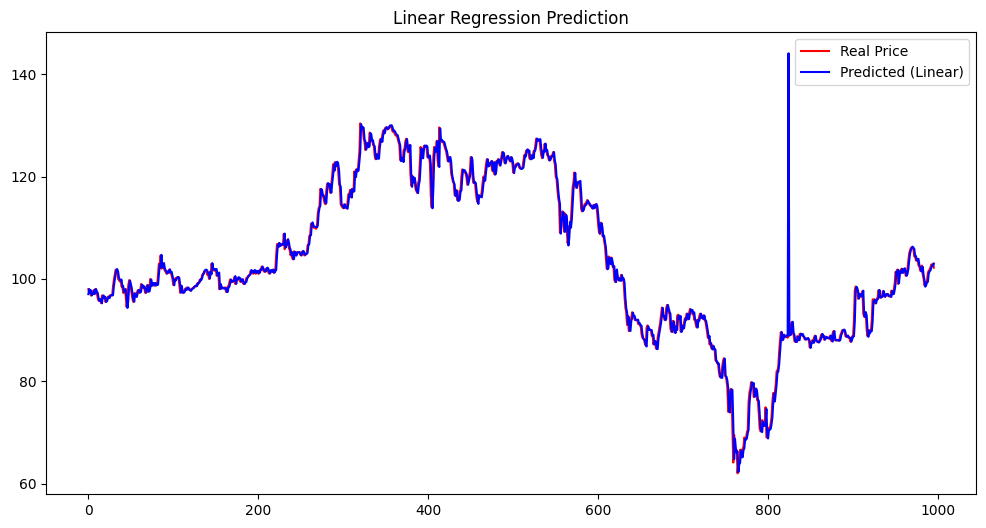


Predicted vs Real:
[[97.02 98.  ]
 [98.01 97.25]
 [97.31 97.75]
 [97.76 96.75]
 [96.76 97.  ]
 [97.13 97.  ]
 [97.09 97.75]
 [97.81 97.  ]
 [97.1  98.  ]
 [98.03 97.5 ]]


In [51]:
import matplotlib.pyplot as plt

# 4. Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test, color='red', label='Real Price')
plt.plot(y_pred, color='blue', label='Predicted (Linear)')
plt.title('Linear Regression Prediction')
plt.legend()
plt.show()

print("\nPredicted vs Real:")
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1)[:10])

In [52]:
from sklearn.metrics import r2_score, mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Accuracy Score (R2): {r2:.4f}")

Root Mean Squared Error (RMSE): 2.20
Accuracy Score (R2): 0.9783
